## README
Kjør i anaconda prompt for å lage geo_env miljø
conda env create -f environment.yml
conda activate geo_env

A. Introduksjon (Markdown)

Problemstilling

Datasett du bruker (kilde + kort beskrivelse)

Kort om metode (buffer, overlay, aggregering, raster)

Forventet output (kart + tabell + eksport)

In [1]:
AREA_NAME = "Kristiansand"
TARGET_CRS = "EPSG:25833"  # meter-basert (UTM33N), egnet for buffer/areal i Norge

B. Setup (Markdown + kode)

imports

paths

versions (valgfritt, men ryddig)

“helper functions” (f.eks. enkel plot-funksjon)

## Sett arbeidsmappe og importer biblioteker
Setter opp miljø og filstier slik at det effektivt kan bli brukt senere i opppgaven

In [2]:
from pathlib import Path
import pandas as pd
import geopandas as gpd
import duckdb

BASE = Path.home() / "Downloads" / "IS-218"
CRS = 25833

## Leser inn tilfluktsrom GoeJSON
Leser inn tilfluktsrom (punkt) for hele Norge og klipper det til Kristiansand.

In [3]:
from pathlib import Path

tilflukt_dir = BASE / "Samfunnssikkerhet_0000_Norge_25833_TilfluktsromOffentlige_GeoJSON"
tilflukt_files = list(tilflukt_dir.rglob("*.geojson")) + list(tilflukt_dir.rglob("*.json"))

tilflukt_path = tilflukt_files[0]   # <-- dette er en Path
tilflukt_path

WindowsPath('C:/Users/arild/Downloads/IS-218/Samfunnssikkerhet_0000_Norge_25833_TilfluktsromOffentlige_GeoJSON/Samfunnssikkerhet_0000_Norge_25833_TilfluktsromOffentlige_GeoJSON.json')

In [4]:
files = list(tilflukt_dir.rglob("*.geojson")) + list(tilflukt_dir.rglob("*.json"))
len(files), [f.name for f in files[:10]]

(1, ['Samfunnssikkerhet_0000_Norge_25833_TilfluktsromOffentlige_GeoJSON.json'])

## Leser inn kommunepolygon for Kristiansand kommune

In [5]:
kommune_file = BASE / "Basisdata_0000_Norge_25833_Kommuner_GeoJSON" / "Basisdata_0000_Norge_25833_Kommune_GeoJSON.geojson"
kommuner = gpd.read_file(kommune_file).to_crs(CRS)

krs = kommuner[kommuner["kommunenavn"] == "Kristiansand"].copy()
krs.shape

(1, 15)

In [6]:
import json
import geopandas as gpd

with open(tilflukt_path, encoding="utf-8") as f:
    data = json.load(f)

tilflukt = gpd.GeoDataFrame.from_features(data["features"], crs=f"EPSG:{CRS}")
tilflukt_krs = gpd.clip(tilflukt, krs)

tilflukt_krs.shape, tilflukt_krs.columns

((35, 10),
 Index(['geometry', 'lokalId', 'navnerom', 'versjonId', 'datauttaksdato',
        'opphav', 'romnr', 'plasser', 'adresse', 'objtype'],
       dtype='str'))

## Koble til DuckDB (filbasert database) og aktiver Spatial SQL

Her oppretter/åpner vi en lokal DuckDB-fil (ingen login). Vi laster `spatial`-utvidelsen slik at vi kan bruke `ST_*`-funksjoner i SQL og lagre geometri som `GEOMETRY` i DuckDB.


In [7]:
DB_PATH = BASE / "analysis.duckdb"
con = duckdb.connect(str(DB_PATH))

# Spatial SQL i DuckDB (install én gang per miljø, load hver gang)
con.execute("INSTALL spatial;")
con.execute("LOAD spatial;")

DB_PATH


WindowsPath('C:/Users/arild/Downloads/IS-218/analysis.duckdb')

## Skriv GeoDataFrames til DuckDB som tabeller (med GEOMETRY)

Vi lagrer både kommunepolygonet (Kristiansand) og tilfluktsrom (punkter) i DuckDB.
Dette gjør at vi kan kjøre romlige SQL-spørringer (f.eks. tellinger, filtrering og joins) i databasen.


In [8]:
def gdf_to_duckdb(con, gdf, table_name: str):
    # Lag en pandas-DF med WKB for robust lagring
    df = pd.DataFrame(gdf.drop(columns="geometry"))
    df["geom_wkb"] = gdf.geometry.to_wkb()

    con.register(f"_{table_name}_raw", df)
    con.execute(f"DROP TABLE IF EXISTS {table_name};")
    con.execute(f'''
        CREATE TABLE {table_name} AS
        SELECT *,
               ST_GeomFromWKB(geom_wkb) AS geom
        FROM _{table_name}_raw;
    ''')
    con.unregister(f"_{table_name}_raw")

gdf_to_duckdb(con, krs.to_crs(TARGET_CRS), "krs_kommune")
gdf_to_duckdb(con, tilflukt_krs.to_crs(TARGET_CRS), "tilflukt_krs")

# Sjekk antall rader
con.execute("SELECT 'krs_kommune' AS tabell, COUNT(*) AS n FROM krs_kommune UNION ALL SELECT 'tilflukt_krs', COUNT(*) FROM tilflukt_krs;").df()


,tabell,n
0,krs_kommune,1
1,tilflukt_krs,35


## Spatial SQL-eksempel: Tell tilfluktsrom i Kristiansand

Her bruker vi SQL i DuckDB til å telle antall tilfluktsrom-punkter som ligger innenfor kommunegeometrien.


In [9]:
con.execute('''
SELECT COUNT(*) AS antall_tilfluktsrom
FROM tilflukt_krs t
JOIN krs_kommune k
  ON ST_Within(t.geom, k.geom);
''').df()


,antall_tilfluktsrom
0,35


## Les inn befolkning (FGDB)
Vi leser inn befolkningsrutenettet (250m) fra en File Geodatabase (FGDB). Først finner vi *.gdb-mappen og lister lagene i den, deretter leser vi riktig lag inn som GeoDataFrame.

In [13]:
from pathlib import Path
import fiona
import geopandas as gpd

pop_gdb_dir = BASE / "Befolkning_0000_Norge_25833_BefolkningsstatistikkRutenett250m2025_FGDB"

# Finn .gdb (skal vanligvis bare være én)
gdb_paths = list(pop_gdb_dir.glob("*.gdb"))
assert len(gdb_paths) > 0, f"Fant ingen .gdb i {pop_gdb_dir}"
gdb = gdb_paths[0]

# List lag i geodatabasen
layers = fiona.listlayers(gdb)
layers

['befolkningparutenett_befolkningparuter250m']

In [14]:
layer_name = layers[0]  # 'befolkningsparutenett_befolkningsparuter250m' hos deg
pop = gpd.read_file(gdb, layer=layer_name)
pop.head(), pop.crs, pop.shape

(                 objtype                               lokalid  \
 0  BefolkningPåRuter250m  72360506-2bbc-4db5-818b-3c92604d66c8   
 1  BefolkningPåRuter250m  b03ac202-9337-4655-9d73-00f692e0e0e9   
 2  BefolkningPåRuter250m  81896cfe-9c39-420a-922f-992b8035320c   
 3  BefolkningPåRuter250m  bc595326-62b4-406d-b234-9c36ba4c02fc   
 4  BefolkningPåRuter250m  274063d2-8734-4624-8537-fabeba4ece01   
 
                                             navnerom versjonid  \
 0  http://data.geonorge.no/sosi/befolkning/befolk...  20250101   
 1  http://data.geonorge.no/sosi/befolkning/befolk...  20250101   
 2  http://data.geonorge.no/sosi/befolkning/befolk...  20250101   
 3  http://data.geonorge.no/sosi/befolkning/befolk...  20250101   
 4  http://data.geonorge.no/sosi/befolkning/befolk...  20250101   
 
   oppdateringsdato      datauttaksdato opphav       ssbid250m  poptot  \
 0       2025-01-01 2025-10-06 10:20:59    SSB  19580006626500      21   
 1       2025-01-01 2025-10-06 10:20:59    S

In [15]:
pop.columns

Index(['objtype', 'lokalid', 'navnerom', 'versjonid', 'oppdateringsdato',
       'datauttaksdato', 'opphav', 'ssbid250m', 'poptot', 'statistikkar',
       'geometry'],
      dtype='str')

## Avgrens til Kristiansand for å gjøre videre analyser
Lastet ned kommunegrenser fra Geonorge.no og lagt til i mappen med alle filer.

In [16]:
kommune_file = BASE / "Basisdata_0000_Norge_25833_Kommuner_GeoJSON" / "Basisdata_0000_Norge_25833_Kommune_GeoJSON.geojson"

kommuner = gpd.read_file(kommune_file).to_crs(25833)

kommuner.geometry.geom_type.value_counts()

MultiPolygon    357
Name: count, dtype: int64

In [17]:
krs = kommuner[kommuner["kommunenavn"] == "Kristiansand"].copy()
krs = krs.to_crs(25833)

krs.shape

(1, 15)

## Klipp ut data til Kristiansand

In [18]:
tilflukt_krs = gpd.clip(tilflukt, krs)
pop_krs = gpd.clip(pop, krs)

tilflukt_krs.shape, pop_krs.shape

((35, 10), (2143, 11))

## DuckDB: Spatial SQL analyse
I denne delen bruker vi DuckDB som databaseverktøy og kjører Spatial SQL (ST_Within/ST_Distance) på de samme datasettene som vi analyserer i GeoPandas. Dette oppfyller kravet om å vise bruk av databaseverktøy i notebooken.

In [34]:
import duckdb

db_path = BASE / "analysis.duckdb"
con = duckdb.connect(str(db_path))

con.execute("INSTALL spatial;")
con.execute("LOAD spatial;")

# ---- send data inn i DuckDB (WKB -> GEOMETRY) ----
til_sql = tilflukt_krs.copy()
til_sql["geom_wkb"] = til_sql.geometry.to_wkb()

krs_sql = krs.copy()
krs_sql["geom_wkb"] = krs_sql.geometry.to_wkb()

con.register("til_raw", til_sql.drop(columns="geometry"))
con.register("krs_raw", krs_sql.drop(columns="geometry"))

con.execute("""
CREATE OR REPLACE TABLE tilflukt AS
SELECT *, ST_GeomFromWKB(geom_wkb) AS geom
FROM til_raw;
""")

con.execute("""
CREATE OR REPLACE TABLE kommune AS
SELECT *, ST_GeomFromWKB(geom_wkb) AS geom
FROM krs_raw;
""")

# ---- Spatial SQL: tell tilfluktsrom innenfor kommunen ----
con.execute("""
SELECT COUNT(*) AS antall_tilfluktsrom
FROM tilflukt t
JOIN kommune k
  ON ST_Within(t.geom, k.geom);
""").df()

,antall_tilfluktsrom
0,35


## Lager buffersone rundt tilfluktsrom for å representere mulig gangavstand. Her brukes 500 m og 1000 m for å sammenligne dekning

In [19]:
import pandas as pd

distances = [500, 1000]  # meter

buffers = []

for d in distances:
    b = tilflukt_krs.copy()
    b["buffer_m"] = d
    b["geometry"] = b.buffer(d)
    buffers.append(b[["buffer_m", "geometry"]])

buffer_gdf = pd.concat(buffers, ignore_index=True)
buffer_gdf.head()

,buffer_m,geometry
0,500,"POLYGON ((94609.001 6469442.999, 94606.594 646..."
1,500,"POLYGON ((91775.001 6469579.999, 91772.594 646..."
2,500,"POLYGON ((94493.001 6469719.999, 94490.594 646..."
3,500,"POLYGON ((94227.001 6469958.999, 94224.594 646..."
4,500,"POLYGON ((91381.001 6472180.999, 91378.594 647..."


## Slå sammen til en flate per avstand

In [20]:
buffer_union = buffer_gdf.dissolve(by="buffer_m").reset_index()
buffer_union

,buffer_m,geometry
0,500,"MULTIPOLYGON (((88080.962 6458343.3, 88055.736..."
1,1000,"MULTIPOLYGON (((88471.471 6458023.429, 88413.0..."


## Visualisering av data

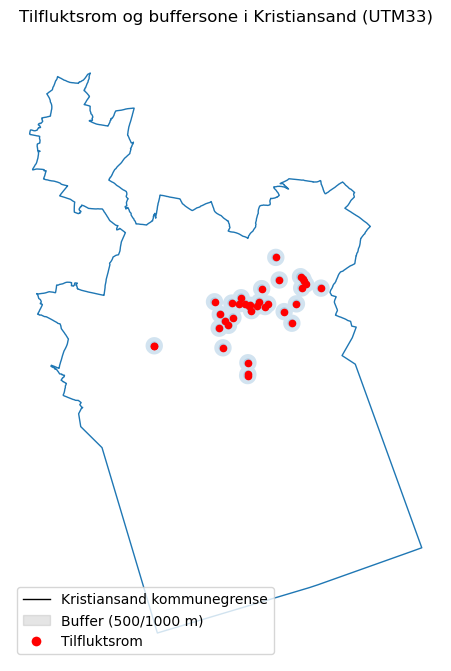

In [21]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

fig, ax = plt.subplots(figsize=(8, 8))

# Kommunegrense
krs.boundary.plot(ax=ax, linewidth=1)

# Bufferflater
buffer_union.plot(ax=ax, alpha=0.2)

# Tilfluktsrompunkter
tilflukt_krs.plot(ax=ax, color="red", markersize=20)

# Lag en enkel legend
legend_elements = [
    Line2D([0], [0], color="black", lw=1, label="Kristiansand kommunegrense"),
    Patch(facecolor="gray", edgecolor="gray", alpha=0.2, label="Buffer (500/1000 m)"),
    Line2D([0], [0], marker="o", color="w", label="Tilfluktsrom",
           markerfacecolor="red", markersize=8),
]

ax.legend(handles=legend_elements, loc="lower left")
ax.set_title("Tilfluktsrom og buffersone i Kristiansand (UTM33)")
ax.set_axis_off()
plt.show()

## Hvor mange mennesker bor i områder som ligger innenfor rekkevidde
Vi beregner hvor mange som bor innenfor 500m og 1000m fra tilfluktsrom ved å gjøre en overlay (intersection) mellom befolkningsruter og bufferflatene. For å unngå dobbelttelling summerer vi per unik rute-id (ssbid250m). Til slutt sammenligner vi mot total befolkning i hele Kristiansand kommune.

In [31]:
POP_COL = "poptot"
ID_COL = "ssbid250m"

buffer_500 = buffer_union[buffer_union["buffer_m"] == 500].copy()
buffer_1000 = buffer_union[buffer_union["buffer_m"] == 1000].copy()

# Overlay (intersection)
pop_in_500 = gpd.overlay(pop_krs[[ID_COL, POP_COL, "geometry"]], buffer_500, how="intersection")
pop_in_1000 = gpd.overlay(pop_krs[[ID_COL, POP_COL, "geometry"]], buffer_1000, how="intersection")

# Summer per unik rute (unngår dobbelttelling hvis ruter splittes i overlay)
bef_500 = pop_in_500.drop_duplicates(ID_COL)[POP_COL].sum()
bef_1000 = pop_in_1000.drop_duplicates(ID_COL)[POP_COL].sum()
bef_total = pop_krs[POP_COL].sum()

df_bef = pd.DataFrame({
    "Område": ["Innen 500m", "Innen 1000m", "Hele kommunen"],
    "Befolkning": [bef_500, bef_1000, bef_total]
})
df_bef["Andel av kommunen"] = df_bef["Befolkning"] / bef_total

df_bef

,Område,Befolkning,Andel av kommunen
0,Innen 500m,55379,0.467696
1,Innen 1000m,81686,0.689869
2,Hele kommunen,118408,1.000000


## Total kapasitet i kommunen for alle tilfluktsrom

In [29]:
total_kapasitet = tilflukt_krs["plasser"].sum()
total_kapasitet

np.int64(7281)

## Sammenligne kapasitet på tilfluktsrom og befolkningsantall i Krisitansand kommune

Kapasiten til tilfluktsrommene er avgjørende for reell dekning.
Selv om et rom er innenfor akseptabel avstand, kan kapasiteten være utilstrekkelig for befolkningen i område

Vi sammenligner samlet kapasitet i tilfluktsrom med befolkningen innenfor 500m, 1000m og hele kommunen for å få en enkel indikator på om kapasiteten kan være tilstrekkelig.

Dekningen viser at det er omtrent 6% av befolkningen innenfor analyseområde som vil kunne få plass i tilfluktsrommet. Dette indikerer en betydelig underdektning dersom alle innbyggere skulle ha behov for tilfluktsrom samtidig.

In [32]:
KAP_COL = "plasser"
total_kapasitet = tilflukt_krs[KAP_COL].sum()

df_kap = pd.DataFrame({
    "Område": ["Innen 500m", "Innen 1000m", "Hele kommunen"],
    "Befolkning": [bef_500, bef_1000, bef_total],
    "Total kapasitet": [total_kapasitet, total_kapasitet, total_kapasitet]
})

df_kap["Kapasitet per person"] = df_kap["Total kapasitet"] / df_kap["Befolkning"]
df_kap["Dekningsgrad (%)"] = 100 * df_kap["Kapasitet per person"]

df_kap

,Område,Befolkning,Total kapasitet,Kapasitet per person,Dekningsgrad (%)
0,Innen 500m,55379,7281,0.131476,13.147583
1,Innen 1000m,81686,7281,0.089134,8.913400
2,Hele kommunen,118408,7281,0.061491,6.149078


## Dekningskart for å vise område som blir dekket av et tilfluktsrom

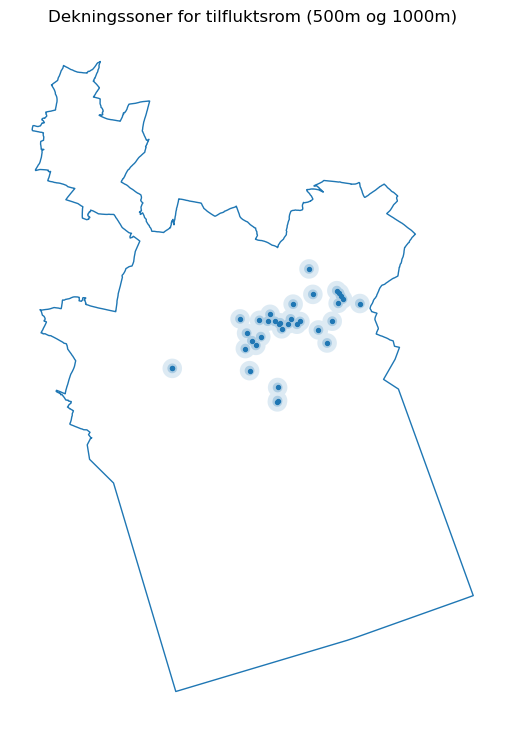

In [33]:
ax = krs.boundary.plot(figsize=(9,9), linewidth=1)
buffer_1000.plot(ax=ax, alpha=0.15)
buffer_500.plot(ax=ax, alpha=0.25)
tilflukt_krs.plot(ax=ax, markersize=8)

ax.set_title("Dekningssoner for tilfluktsrom (500m og 1000m)")
ax.set_axis_off()

## Rasteranalyse (DEM , slope, >30 grader, polygonize, hillshade
I denne delen dokumenteres rasterarbeidsflyten med GDAL CLI. Vi bruker en DEM (GeoTIFF) for et valgt område i/ved Kristiansand.

Områder med helning over 30 grader kan være vanskeligere å ferdes i, og kan dermed påvirke reell tilgjengelighet til tilfluktsrom i en evakueringssituasjon

## Slår sammen begge raster filene for å lage en fil som har innholdet til begge filene i Anaconda prompt
python -m osgeo_utils.gdal_merge -o dem_merge.tif Basisdata_7910-2_Celle_25833_DTM10UTM33_TIFF\7910_2_10m_z33.tif Basisdata_7910-3_Celle_25833_DTM10UTM33_TIFF\7910_3_10m_z33.tif

## Lager helningskart
gdaldem slope dem_merge.tif slope.tif

## Filtrer områder med helning >30 grader
python -m osgeo_utils.gdal_calc -A slope.tif --outfile=slope_gt30.tif --calc="A>30" --NoDataValue=0

## Polygonize helningsfilen
python -m osgeo_utils.gdal_polygonize slope_gt30.tif -f "GPKG" slope_gt30.gpkg bratthet layer_bratthet

## Hillshade
gdaldem hillshade dem_merge.tif hillshade_az315_alt45.tif -az 315 -alt 45
gdaldem hillshade dem_merge.tif hillshade_az135_alt30.tif -az 135 -alt 30

## Bratt terreng og tilfluktsrom
Vi visualiserer områder med helning over 30 grader sammen med tilfluktsrommene for å undersøke om bratt terreng kan påvirke tilgjengeligheten

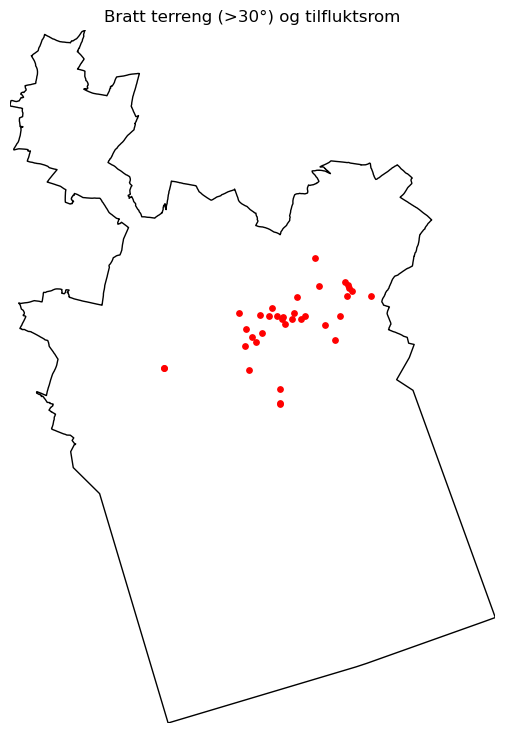

In [39]:
fig, ax = plt.subplots(figsize=(9, 9))

# Plott kommune først (styrer extent)
krs.plot(ax=ax, facecolor="none", edgecolor="black", linewidth=1)

# Plott bratt terreng
bratt.plot(ax=ax, color="orange", alpha=0.5)

# Plott tilfluktsrom
tilflukt_krs.plot(ax=ax, color="red", markersize=15)

# Tving zoom til kommunegrense
minx, miny, maxx, maxy = krs.total_bounds
ax.set_xlim(minx, maxx)
ax.set_ylim(miny, maxy)

ax.set_title("Bratt terreng (>30°) og tilfluktsrom")
ax.set_axis_off()

In [40]:
# Sørg for samme CRS
bratt = bratt.to_crs(tilflukt_krs.crs)

# Finn tilfluktsrom som ligger i bratte polygoner
til_i_bratt = gpd.sjoin(tilflukt_krs, bratt, predicate="within")

len(til_i_bratt), len(tilflukt_krs)

(0, 35)

## Analysen viser ingen tilfluktsrom som ligger med helning over 30 grader
Analysen viser at ingen tilfluktsrom (punktet) ligger i polygon med helning over 30 grader. 
Dette indikerer at plasseringen av tilfluktsrom ikke er direkte påvirket av svært bratt terreng.

Bratt topografi kan imidlertid fortsatt påvirke tilgjengelighet fra enkelte deler av kommunen, 
selv om selve tilfluktsrommene er plassert i relativt flate områder.

C:\Users\arild\AppData\Local\Temp\ipykernel_34008\2948399735.py:5: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.
  til_i_bratt.plot(ax=ax, markersize=40)  # de som ligger i bratt terreng


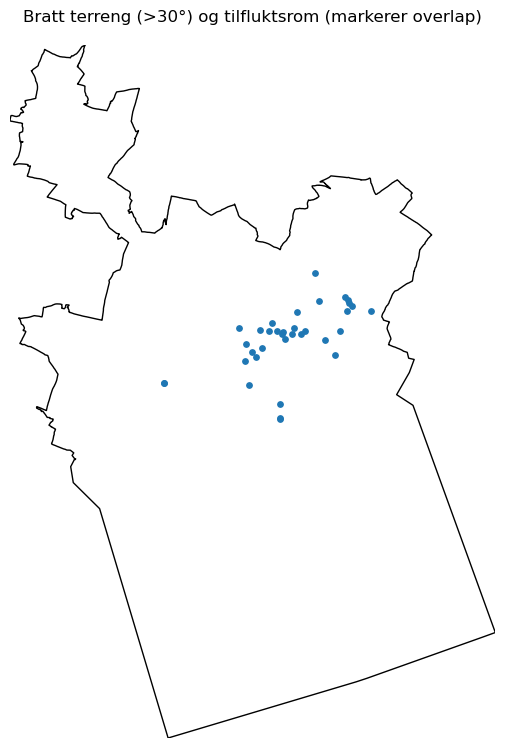

In [41]:
fig, ax = plt.subplots(figsize=(9, 9))
krs.plot(ax=ax, facecolor="none", edgecolor="black", linewidth=1)
bratt.plot(ax=ax, alpha=0.5)
tilflukt_krs.plot(ax=ax, markersize=15)
til_i_bratt.plot(ax=ax, markersize=40)  # de som ligger i bratt terreng

minx, miny, maxx, maxy = krs.total_bounds
ax.set_xlim(minx, maxx); ax.set_ylim(miny, maxy)
ax.set_title("Bratt terreng (>30°) og tilfluktsrom (markerer overlap)")
ax.set_axis_off()

## Konklusjon over analysen
## Konklusjon

Analysen viser at det finnes 35 tilfluktsrom i Kristiansand kommune. 
Ved å etablere buffersoner på 500 meter og 1000 meter rundt hvert tilfluktsrom har vi beregnet hvor mange innbyggere som bor innenfor gangavstand til et tilfluktsrom.

Resultatene viser at en betydelig andel av befolkningen bor innenfor 1000 meter fra et tilfluktsrom, mens færre bor innenfor 500 meter. Når vi sammenligner dette med total kapasitet (antall tilgjengelige plasser), ser vi at kapasiteten er betydelig lavere enn antall innbyggere innenfor rekkevidde. Dette indikerer at selv om mange geografisk sett bor nær et tilfluktsrom, er det ikke tilstrekkelig kapasitet til å dekke hele befolkningen.

Rasteranalysen av terreng (helning > 30 grader) viser at enkelte områder har bratt topografi. Slike områder kan påvirke faktisk tilgjengelighet i en evakueringssituasjon, selv om de ligger innenfor bufferavstandene. Terrengforhold er derfor en viktig faktor som kan redusere reell tilgjengelighet sammenlignet med teoretisk gangavstand.

Samlet sett viser analysen at geografisk dekning alene ikke er tilstrekkelig for å vurdere beredskap. Både kapasitet og terrengforhold må tas i betraktning for å vurdere hvor godt kommunen er rustet i en krisesituasjon. Dette gir et mer helhetlig bilde av beredskapen i tråd med tematikken rundt totalforsvar og samfunnssikkerhet.

In [ ]:
C. Data ingest: vektor 1 (Markdown + kode)

Les inn dataset 1 (f.eks. geopackage)

Sjekk CRS, bounding box, kolonner

Rens/velg relevante felt

In [ ]:
D. Data ingest: vektor 2 (Markdown + kode)

Les inn dataset 2 (f.eks. geoparquet)

Samme sjekk

E. Data ingest: database/API (Markdown + kode)

DuckDB: les geoparquet inn i DuckDB-tabell og gjør en SQL-select

(Her oppfyller du “kobling til database” kravet)

In [ ]:
F. Harmoniser CRS (Markdown + kode)

Reprojiser til meter-basert CRS før buffer: ofte EPSG:25833 (UTM33N) i Norge

Forklar hvorfor: buffer i meter gir mening først når CRS er i meter

In [ ]:
G. Filtrering + visualisering (Markdown + kode)

Attributtfilter eller spatial filter

Eksempel: “skoler i Sagene” (krever bydelsgrenser)

eller: “skoler innenfor Oslo kommune”

Plot resultatet med geopandas.plot() (enkelt) eller folium (pent)

In [ ]:
H. Buffer (Markdown + kode)

Buffer 500 m rundt kollektivknutepunkt

Visualiser buffersoner + skoler

In [ ]:
I. Overlay (Markdown + kode)

Intersection / difference / union

Eks: “Hvilke parkpolygoner overlapper bratt terreng polygoner?”

Eller: “Hvilke boligområder ligger innenfor støysonen?” (om du velger støy)

In [ ]:
J. Aggregasjon (Markdown + kode)

Minst én romlig aggregasjon, typisk:

sjoin skoler (punkt) med buffer (polygon), tell antall skoler per buffer/knutepunkt

eller overlay bratt terreng ∩ parker → beregn areal bratt park per bydel/kommune

Resultat: tabell (Pandas) + gjerne et barplot (valgfritt)

In [ ]:
K. Rasterdel (Markdown med CLI + evt. kode for lesing av output)

Du kan dokumentere med CLI-kommandoer i Markdown (det står eksplisitt at det er greit).

    Stegene du må vise:

Last ned DEM (valgfritt område)

gdaldem slope → slope raster

threshold > 30° (gdal_calc eller rasterio)

polygonize til vektor (gdal_polygonize)

to hillshades med ulike parametere (azimuth/altitude/z-factor)

In [ ]:
L. Eksport + konklusjon (Markdown + kode)

Eksporter vektorfiler til outputs/

Kort konklusjon: hva fant du, hva betyr det